In [ ]:

!git clone https://github.com/fburlacu/ds-ts-project.git

Cloning into 'ds-ts-project'...
remote: Enumerating objects: 87428, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 87428 (delta 31), reused 17 (delta 10), pack-reused 87367 (from 3)
Receiving objects: 100% (87428/87428), 1.69 GiB | 23.35 MiB/s, done.
Resolving deltas: 100% (10145/10145), done.
Updating files: 100% (87280/87280), done.


In [ ]:

!pip install numpy pandas scikit-learn matplotlib tqdm
!pip install git+https://github.com/moment-timeseries-foundation-model/moment.git

  Cloning https://github.com/moment-timeseries-foundation-model/moment.git to /tmp/pip-req-build-5po5seqt
  Running command git clone --filter=blob:none --quiet https://github.com/moment-timeseries-foundation-model/moment.git /tmp/pip-req-build-5po5seqt
  Resolved https://github.com/moment-timeseries-foundation-model/moment.git to commit 38f7310ad594100747ca2a8357e9c7ca7d323e0e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for momentfm: filename=momentfm-0.1.5-py3-none-any.whl size=34253 sha256=acd989aea45263d83218417ad034b459421cdce4e828990bd0caa7c746e66086
  Stored in directory: /tmp/pip-ephem-wheel-cache-vx5s_24s/wheels/d4/4c/8a/a636e1a7e41d9fdfa5c6dd584d6b9f7c447a252d098899a73c
Successfully built momentfm


In [ ]:

!pip install wfdb pandas numpy torch scikit-learn matplotlib seaborn transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 113.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have 

In [ ]:
from momentfm import MOMENTPipeline

model = MOMENTPipeline.from_pretrained(
     "AutonLab/MOMENT-1-small",
    model_kwargs={
        'task_name' : 'classification',
        'n_channels': 12,
        'num_class': 2,
        'freeze_encoder': True,
        'freeze_embedder': True,
        'freeze_head': False,
        'enable_gradient_checkpointing': False,
        'reduction': 'mean',
    },
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/947 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/152M [00:00<?, ?B/s]

In [ ]:
model.init()
print(model)

MOMENTPipeline(
  (normalizer): RevIN()
  (tokenizer): Patching()
  (patch_embedding): PatchEmbedding(
    (value_embedding): Linear(in_features=8, out_features=512, bias=False)
    (position_embedding): PositionalEmbedding()
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (

/usr/local/lib/python3.12/dist-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")


In [ ]:
import os
import ast
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR



from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
SAMPLING_RATE = 100          # 100Hz → 1000 timesteps
N_LEADS       = 12
SEQ_LEN       = 1000
RANDOM_STATE  = 42

DATA_DIR = '/content/ds-ts-project/ecg-dataset/PTBXL/'

def is_normal(scp_dict):
        for code in scp_dict:
            if code == "NORM":
                return 0
        return 1



def load_ptbxl(data_dir, sampling_rate=100):
    """Load PTB-XL signals and binary labels (NORM=1, Abnormal=0)."""
    df = pd.read_csv(os.path.join(data_dir, 'ptbxl_database.csv'), index_col='ecg_id')
    df.scp_codes = df.scp_codes.apply(ast.literal_eval)

    df['label'] = df.scp_codes.apply(is_normal)

    print(f"Dataset size : {len(df)}")
    print(f"Normal       : {df['label'].sum()} ({df['label'].mean()*100:.1f}%)")
    print(f"Abnormal     : {(1-df['label']).sum()} ({(1-df['label'].mean())*100:.1f}%)")

    filename_col = 'filename_lr' if sampling_rate == 100 else 'filename_hr'
    signals = []
    for _, row in df.iterrows():
        path = os.path.join(data_dir, row[filename_col])
        sig, _ = wfdb.rdsamp(path)
        signals.append(sig)

    X = np.stack(signals).transpose(0, 2, 1)
    y = df['label'].values
    return X, y



def normalize(X_train, X_val, X_test):
    """Standardize per-lead using training set statistics only."""
    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
    return (X_train-mean)/std, (X_val-mean)/std, (X_test-mean)/std


X, y = load_ptbxl(DATA_DIR, SAMPLING_RATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val   = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=RANDOM_STATE)

X_train, X_val, X_test = normalize(X_train, X_val, X_test)

print(f"\nSplit sizes → train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")


Dataset size : 21799
Normal       : 12285 (56.4%)
Abnormal     : 9514 (43.6%)

Split sizes → train: 15695, val: 1744, test: 4360


In [ ]:
BATCH_SIZE = 16

class PTBXLDataset(Dataset):
    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


train_loader = DataLoader(PTBXLDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(PTBXLDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(PTBXLDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

sample_X, sample_y = next(iter(train_loader))
print(f"Input shape per batch: {sample_X.shape}")
print(f"Batches per epoch → train: {len(train_loader)}, val: {len(val_loader)}")

Input shape per batch: torch.Size([16, 12, 1000])
Batches per epoch → train: 981, val: 109


In [ ]:
def train_epoch(model, device, train_dataloader, criterion, optimizer, scheduler, reduction='mean'):

    model.to(device)
    model.train()
    losses = []

    for batch_x, batch_labels in tqdm(train_dataloader, desc="Training", leave=False):
        optimizer.zero_grad()
        batch_x = batch_x.to(device).float()
        batch_labels = batch_labels.to(device)


        with torch.autocast(device_type='cuda', dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8 else torch.float32):
            output = model(x_enc=batch_x, reduction=reduction)
            loss = criterion(output.logits, batch_labels)
        loss.backward()

        optimizer.step()
        scheduler.step()
        losses.append(loss.item())

    avg_loss = np.mean(losses)
    return avg_loss

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import numpy as np
import torch
def evaluate_epoch(dataloader, model, criterion, device, phase='val', reduction='mean'):
    model.eval()
    model.to(device)
    total_loss, total_correct = 0, 0
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_labels in dataloader:
            batch_x = batch_x.to(device).float()
            batch_labels = batch_labels.to(device)

            output = model(x_enc=batch_x, reduction=reduction)
            logits = output.logits

            loss = criterion(output.logits, batch_labels)
            total_loss += loss.item()
            probs = torch.softmax(logits, dim=1)

            preds = torch.argmax(probs, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs[:,1].cpu().numpy())
            all_labels.append(batch_labels.cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)

    avg_loss = total_loss / len(dataloader)
    accuracy = (y_pred == y_true).mean()
    roc_auc = roc_auc_score(y_true, y_prob)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    report = classification_report(y_true, y_pred, digits=4)
    return avg_loss, accuracy, roc_auc, report, macro_f1

In [ ]:
from tqdm import tqdm
import numpy as np
import torch

epoch = 10
patience = 2

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.head.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3, total_steps=epoch * len(train_loader)
)

device = 'cuda'

best_val_loss = float('inf')
epochs_no_improve = 0

for i in (range(epoch)):
    train_loss = train_epoch(model, device, train_loader, criterion, optimizer, scheduler)
    val_loss, val_accuracy, val_auc, val_report, macro_f1 = evaluate_epoch(val_loader, model, criterion, device, phase='test')

    print(f'Epoch {i}, train loss: {train_loss}, val loss: {val_loss}, val accuracy: {val_accuracy}, val roc-auc: {val_auc}, macro f1 : {macro_f1}')

    print(val_report)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print("Early stopping triggered!")
        break



Epoch 0, train loss: 0.6563440250815723, val loss: 0.5954187044856745, val accuracy: 0.6657110091743119, val roc-auc: 0.8623484920387722, macro f1 : 0.5935123621173057
              precision    recall  f1-score   support

           0     0.8589    0.2799    0.4222       761
           1     0.6337    0.9644    0.7648       983

    accuracy                         0.6657      1744
   macro avg     0.7463    0.6221    0.5935      1744
weighted avg     0.7319    0.6657    0.6153      1744



Epoch 1, train loss: 0.5398908769987166, val loss: 0.46280133724212646, val accuracy: 0.7930045871559633, val roc-auc: 0.8866940351280572, macro f1 : 0.7853662860366926
              precision    recall  f1-score   support

           0     0.8058    0.6925    0.7449       761
           1     0.7853    0.8708    0.8259       983

    accuracy                         0.7930      1744
   macro avg     0.7956    0.7817    0.7854      1744
weighted avg     0.7943    0.7930    0.7905      1744



Epoch 2, train loss: 0.4541834490743981, val loss: 0.40532857247995674, val accuracy: 0.8188073394495413, val roc-auc: 0.9003439549877483, macro f1 : 0.8169430272108844
              precision    recall  f1-score   support

           0     0.7757    0.8226    0.7985       761
           1     0.8559    0.8159    0.8354       983

    accuracy                         0.8188      1744
   macro avg     0.8158    0.8192    0.8169      1744
weighted avg     0.8209    0.8188    0.8193      1744



Epoch 3, train loss: 0.4229793358560002, val loss: 0.4037645501554559, val accuracy: 0.8193807339449541, val roc-auc: 0.9069864436551467, macro f1 : 0.8192994003289951
              precision    recall  f1-score   support

           0     0.7357    0.9146    0.8155       761
           1     0.9185    0.7457    0.8231       983

    accuracy                         0.8194      1744
   macro avg     0.8271    0.8301    0.8193      1744
weighted avg     0.8388    0.8194    0.8198      1744



Epoch 4, train loss: 0.40896066328345454, val loss: 0.3779240504864159, val accuracy: 0.8302752293577982, val roc-auc: 0.9098097352763069, macro f1 : 0.8293560125243293
              precision    recall  f1-score   support

           0     0.7719    0.8673    0.8168       761
           1     0.8864    0.8016    0.8419       983

    accuracy                         0.8303      1744
   macro avg     0.8292    0.8345    0.8294      1744
weighted avg     0.8364    0.8303    0.8310      1744



Epoch 5, train loss: 0.40129120658540096, val loss: 0.3734544118473289, val accuracy: 0.8348623853211009, val roc-auc: 0.9122667475867673, macro f1 : 0.8341537506521295
              precision    recall  f1-score   support

           0     0.7722    0.8817    0.8233       761
           1     0.8971    0.7986    0.8450       983

    accuracy                         0.8349      1744
   macro avg     0.8346    0.8402    0.8342      1744
weighted avg     0.8426    0.8349    0.8355      1744



Epoch 6, train loss: 0.3966601107584713, val loss: 0.37328734201028807, val accuracy: 0.8348623853211009, val roc-auc: 0.9129692285275439, macro f1 : 0.8343176528334151
              precision    recall  f1-score   support

           0     0.7678    0.8909    0.8248       761
           1     0.9036    0.7915    0.8438       983

    accuracy                         0.8349      1744
   macro avg     0.8357    0.8412    0.8343      1744
weighted avg     0.8444    0.8349    0.8355      1744



Epoch 7, train loss: 0.3938279643913049, val loss: 0.3678019296958906, val accuracy: 0.8337155963302753, val roc-auc: 0.9134150465936693, macro f1 : 0.8328150122704578
              precision    recall  f1-score   support

           0     0.7754    0.8712    0.8205       761
           1     0.8898    0.8047    0.8451       983

    accuracy                         0.8337      1744
   macro avg     0.8326    0.8380    0.8328      1744
weighted avg     0.8399    0.8337    0.8344      1744



Epoch 8, train loss: 0.391936414042501, val loss: 0.36826851854630566, val accuracy: 0.8342889908256881, val roc-auc: 0.9135995230348246, macro f1 : 0.8335138527602295
              precision    recall  f1-score   support

           0     0.7731    0.8778    0.8222       761
           1     0.8943    0.8006    0.8449       983

    accuracy                         0.8343      1744
   macro avg     0.8337    0.8392    0.8335      1744
weighted avg     0.8414    0.8343    0.8350      1744



Epoch 9, train loss: 0.3916192172697074, val loss: 0.3694873051632435, val accuracy: 0.8360091743119266, val roc-auc: 0.9136289323225449, macro f1 : 0.8353541715355597
              precision    recall  f1-score   support

           0     0.7721    0.8857    0.8250       761
           1     0.9001    0.7976    0.8457       983

    accuracy                         0.8360      1744
   macro avg     0.8361    0.8416    0.8354      1744
weighted avg     0.8442    0.8360    0.8367      1744

Early stopping triggered!


In [ ]:
test_loss, test_acc, test_auc, test_report ,macro_f1  = evaluate_epoch(
    test_loader, model, criterion, device
)

print(f"""
TEST RESULTS
------------
Loss: {test_loss:.4f}
Accuracy: {test_acc:.4f}
ROC-AUC: {test_auc:.4f}
macro :{macro_f1:.4f}
""")

print(test_report)


TEST RESULTS
------------
Loss: 0.4020
Accuracy: 0.8138
ROC-AUC: 0.8969
macro :0.8131

              precision    recall  f1-score   support

           0     0.7485    0.8634    0.8019      1903
           1     0.8799    0.7753    0.8243      2457

    accuracy                         0.8138      4360
   macro avg     0.8142    0.8194    0.8131      4360
weighted avg     0.8226    0.8138    0.8145      4360



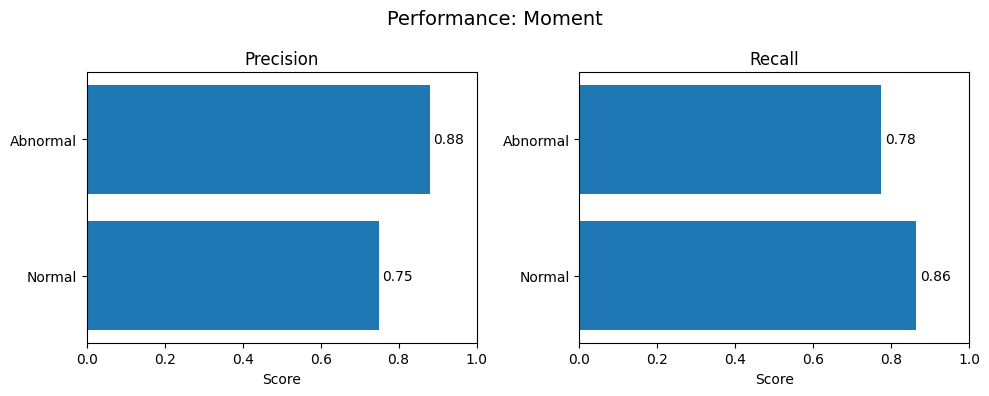

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


labels = ["Normal", "Abnormal"]

precision = [0.7485, 0.8799]
recall = [0.8634, 0.7753]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))


axes[0].barh(labels, precision)
axes[0].set_xlim(0, 1.0)
axes[0].set_title("Precision")
axes[0].set_xlabel("Score")

for i, v in enumerate(precision):
    axes[0].text(v + 0.01, i, f"{v:.2f}", va="center")


axes[1].barh(labels, recall)
axes[1].set_xlim(0, 1.0)
axes[1].set_title("Recall")
axes[1].set_xlabel("Score")

for i, v in enumerate(recall):
    axes[1].text(v + 0.01, i, f"{v:.2f}", va="center")

plt.suptitle("Performance: Moment", fontsize=14)
plt.tight_layout()
plt.show()